In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

In [79]:
 X,y = load_diabetes(return_X_y = True)

In [80]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=43)

In [81]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [82]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [83]:
weights = np.zeros(X_train.shape[1])
bias = 0
print('Weights:', weights)
print('Bias:',bias)
print('Wights shape:',weights.shape)
learning_rate = 0.01
epochs = 1000
y_pred = X_train@weights + bias
print(y_pred[:5])


Weights: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Bias: 0
Wights shape: (10,)
[0. 0. 0. 0. 0.]


In [84]:
error = y_pred - y_train
print(error[:5])

[-202.  -55. -202.  -42. -214.]


In [85]:
cost = np.mean(error ** 2)
print("cost:" , cost)

cost: 29093.03682719547


In [86]:
dw = (2/len(X_train))*(X_train.T@ error)
db = (2/len(X_train))*(np.sum(error))
np.sum(error)
print("dw:",dw)
print("db:",db)
                       

dw: [-19.86680878  -7.34420012 -88.12762951 -59.42215661 -32.24193649
 -25.03921138  58.36684772 -65.91564664 -89.15367253 -52.72845625]
db: -304.90651558073654


In [87]:
weights = weights - learning_rate*dw
bias = bias - learning_rate*db
print('updated weights:', weights)
print('updated bias:', bias)

updated weights: [ 0.19866809  0.073442    0.8812763   0.59422157  0.32241936  0.25039211
 -0.58366848  0.65915647  0.89153673  0.52728456]
updated bias: 3.0490651558073654


In [88]:
cost_history = []
for i in range(epochs):
    y_pred = X_train@weights + bias
    error = y_pred - y_train
    cost = np.mean(error ** 2)
    cost_history.append(cost)
    dw = (2/len(X_train))*(X_train.T@ error)
    db = (2/len(X_train))*(np.sum(error))

    weights = weights - learning_rate*dw
    bias = bias - learning_rate*db

    print('Final cost:', cost_history[-1])
    print('Final Bias:', bias)
    print('Final weights:' , weights)

Final cost: 27865.056102632847
Final Bias: 6.037149008498584
Final weights: [ 0.37230621  0.12384176  1.71515709  1.14857579  0.60577641  0.46173314
 -1.12661063  1.26241845  1.72877326  1.01077458]
Final cost: 26715.377375689215
Final Bias: 8.965471184135978
Final weights: [ 0.52312298  0.15333898  2.50499214  1.666106    0.85358802  0.63763712
 -1.63191378  1.81436442  2.51579616  1.45394996]
Final cost: 25636.297548499857
Final Bias: 11.835226916260625
Final weights: [ 0.65314433  0.16389666  3.25387001  2.14961326  1.06907613  0.78141401
 -2.10242164  2.31920099  3.25636671  1.86001139]
Final cost: 24621.133354736
Final Bias: 14.64758753374278
Final weights: [ 0.76422841  0.15731541  3.96463901  2.60167596  1.25519193  0.89609462
 -2.54075383  2.78079304  3.9539472   2.23190291]
Final cost: 23664.069872475335
Final Bias: 17.40370093887529
Final weights: [ 0.85807923  0.13524663  4.63992643  3.02466772  1.41463808  0.98445353
 -2.94932389  3.20269144  4.61172499  2.57233262]
Final c

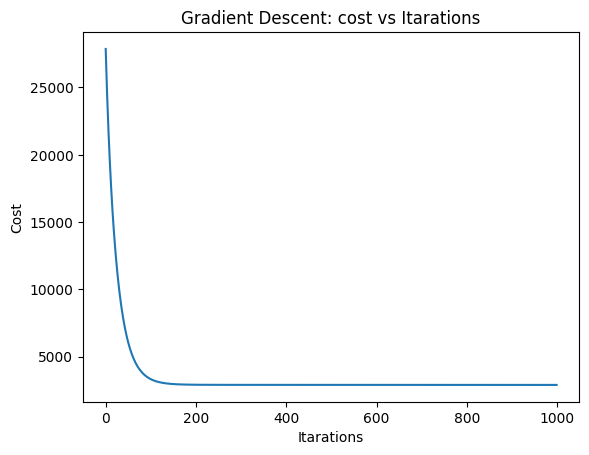

In [89]:
plt.plot(cost_history)
plt.xlabel('Itarations')
plt.ylabel('Cost')
plt.title('Gradient Descent: cost vs Itarations' )
plt.show()

In [90]:
y_test_pred = X_test@weights + bias
print(y_test_pred[:5])

[109.83700083  98.17054055 168.8218076  266.71381672 194.16007993]


In [91]:
r2 = r2_score(y_test,y_test_pred)
print("R2 score" ,r2)

R2 score 0.5380995419356767


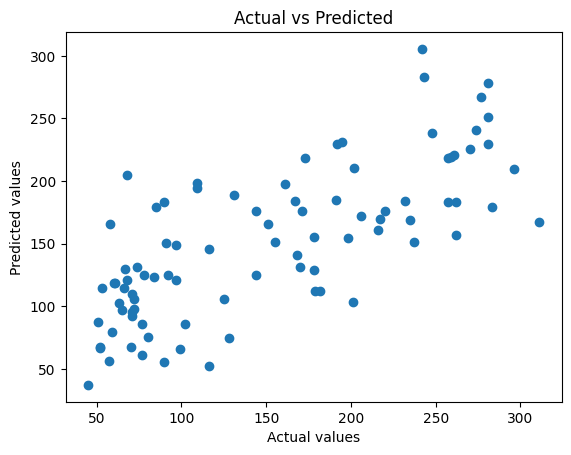

In [92]:
plt.scatter(y_test,y_test_pred)
plt.xlabel("Actual values")
plt.ylabel('Predicted values')
plt.title('Actual vs Predicted')
plt.show()